# 경제지표 기반 경기 흐름 분석 및 AI 활용 미니 프로젝트

## 프로젝트 목적
2019년부터 2025년까지의 소비자물가지수, 한국은행 기준금리, 원/달러 환율 데이터를 활용해 한국 경제 흐름을 분석한다.

분석 결과를 Gemini AI를 사용하여 일반 사용자도 이해하기 쉬운 경제 리포트 형태로 요약하도록 프롬프트를 구성하고 질문하여 요약 답변을 받을 수 있게 한다.

## 사용 기술
- Python
- pandas
- matplotlib
- Google Colab
- Gemini AI



In [ ]:
from google.colab import files # 구글 코랩으로부터 파일 업로드 도구를 불러오기
files.upload()                 # 업로드 실행

Saving 환율.csv to 환율.csv
Saving 기준금리.csv to 기준금리.csv
Saving 소비자물가지수.csv to 소비자물가지수.csv


{'환율.csv': b'\xef\xbb\xbf\xeb\xb3\x80\xed\x99\x98,\xec\x9b\x90\xec\x9e\x90\xeb\xa3\x8c\n"2019-01","1,122.00"\n"2019-02","1,122.45"\n"2019-03","1,130.72"\n"2019-04","1,140.95"\n"2019-05","1,183.29"\n"2019-06","1,175.62"\n"2019-07","1,175.31"\n"2019-08","1,208.98"\n"2019-09","1,197.55"\n"2019-10","1,184.13"\n"2019-11","1,167.45"\n"2019-12","1,175.84"\n"2020-01","1,164.28"\n"2020-02","1,193.79"\n"2020-03","1,220.09"\n"2020-04","1,225.23"\n"2020-05","1,228.67"\n"2020-06","1,210.01"\n"2020-07","1,198.90"\n"2020-08","1,186.85"\n"2020-09","1,178.80"\n"2020-10","1,144.68"\n"2020-11","1,116.76"\n"2020-12","1,095.13"\n"2021-01","1,097.49"\n"2021-02","1,111.72"\n"2021-03","1,131.02"\n"2021-04","1,119.40"\n"2021-05","1,123.28"\n"2021-06","1,121.30"\n"2021-07","1,143.98"\n"2021-08","1,160.34"\n"2021-09","1,169.54"\n"2021-10","1,182.82"\n"2021-11","1,182.91"\n"2021-12","1,183.70"\n"2022-01","1,194.01"\n"2022-02","1,198.34"\n"2022-03","1,221.03"\n"2022-04","1,232.34"\n"2022-05","1,269.88"\n"2022-06",

In [ ]:
import pandas as pd   # import = 꺼내쓴다, pandas = 행,열로 된 데이터 표를 다루는 도구
                      # as pd = pandas를 pd라는 짧은 이름으로 명명
                      # 표를 다루는 도구를 꺼내고 pd로 명명한다는 코드

**pandas = 엑셀처럼 표 형태로 데이터를 다룰 수 있게 해주는 도구**

In [ ]:
df_cpi = pd.read_csv('소비자물가지수.csv') # pandas가 csv 파일을 읽어서 df_cpi라는 변수에 표로 저장

print(df_cpi.head())                       # df_cpi의 앞부분 5개의 데이터를 보여줘

        시점      전국
0  2019-01  98.884
1  2019-02  99.311
2  2019-03  99.121
3  2019-04  99.481
4  2019-05  99.652


In [ ]:
df_br = pd.read_csv('기준금리.csv') # pandas가 csv 파일을 읽어서 df_br라는 변수에 표로 저장

print(df_br.head())                 # df_br의 앞부분 5개의 데이터를 보여줘

        변환   원자료
0  2019-01  1.75
1  2019-02  1.75
2  2019-03  1.75
3  2019-04  1.75
4  2019-05  1.75


In [ ]:
df_er = pd.read_csv('환율.csv')     # pandas가 csv 파일을 읽어서 df_er 라는 변수에 표로 저장

print(df_er.head())                 # df_er의 앞부분 5개의 데이터를 보여줘

        변환       원자료
0  2019-01  1,122.00
1  2019-02  1,122.45
2  2019-03  1,130.72
3  2019-04  1,140.95
4  2019-05  1,183.29


**세 개의 데이터를 날짜 기준으로 합치려면 이름이 같아야 한다**

In [ ]:
print(df_cpi.columns)               # df_cpi 의 컬럼(열) 이름을 보여줘
print(df_br.columns)                # df_br 의 컬럼(열) 이름을 보여줘
print(df_er.columns)                # df_er 의 컬럼(열) 이름을 보여줘

Index(['시점', '전국'], dtype='object')
Index(['변환', '원자료'], dtype='object')
Index(['변환', '원자료'], dtype='object')


**컬럼들의 이름이 다르므로 같게 해줘야 한다**

In [ ]:
df_cpi = df_cpi.rename(columns={'시점' :'date', '전국': 'cpi'}) # df_cpi 컬럼(열) 의 이름들을 rename()을 사용하여 시점을 date로, 전국을 cpi로 바꿔준다.

print(df_cpi.columns)                                           # 바뀌었는지 확인

Index(['date', 'cpi'], dtype='object')


In [ ]:
df_br = df_br.rename(columns={'변환':'date','원자료':'rate'})   # 위와 같은 방식으로 진행

print(df_br.columns)                                            # 바뀌었는지 확인

Index(['date', 'rate'], dtype='object')


In [ ]:
df_er = df_er.rename(columns={'변환':'date', '원자료':'usd_krw'}) # 위와 같은 방식으로 진행

print(df_er.columns)                                              # 바뀌었는지 확인

Index(['date', 'usd_krw'], dtype='object')


**날짜 컬럼의 형태들이 같은지도 확인해 준다**

In [ ]:
print(df_cpi['date'].head()) # date 컬럼을 꺼내서 df_cpi의 앞부분 5개 데이터를 보여줘

0    2019-01
1    2019-02
2    2019-03
3    2019-04
4    2019-05
Name: date, dtype: object


In [ ]:
print(df_br['date'].head()) # date 컬럼을 꺼내서 df_br의 앞부분 5개 데이터를 보여줘

0    2019-01
1    2019-02
2    2019-03
3    2019-04
4    2019-05
Name: date, dtype: object


In [ ]:
print(df_er['date'].head()) # date 컬럼을 꺼내서 df_er의 앞부분 5개 데이터를 보여줘

0    2019-01
1    2019-02
2    2019-03
3    2019-04
4    2019-05
Name: date, dtype: object


# 날짜들이 현재 문자 데이터로 되어있어 date 컬럼을 날짜 타입으로 변경

In [ ]:
df_cpi['date'] = pd.to_datetime(df_cpi['date']) # pd.to_datetime() = 값을 날짜 형식으로 변환
                                                # df_cpi 의 date 컬럼(열) 을 날짜 형식으로 변환

df_br['date'] = pd.to_datetime(df_br['date'])   # 위와 같은 방식으로 진행

df_er['date'] = pd.to_datetime(df_er['date'])

In [ ]:
print(df_cpi.dtypes)          # 각 데이터의 타입 확인
print(df_br.dtypes)           # datetime64[ns] = 날짜/시간 타입으로 변환된 모습 확인
print(df_er.dtypes)

date    datetime64[ns]
cpi            float64
dtype: object
date    datetime64[ns]
rate           float64
dtype: object
date       datetime64[ns]
usd_krw            object
dtype: object


In [ ]:
print(df_cpi['date'].head())   # 각 데이터의 date 컬럼(열) 확인
print(df_br['date'].head())
print(df_er['date'].head())

0   2019-01-01
1   2019-02-01
2   2019-03-01
3   2019-04-01
4   2019-05-01
Name: date, dtype: datetime64[ns]
0   2019-01-01
1   2019-02-01
2   2019-03-01
3   2019-04-01
4   2019-05-01
Name: date, dtype: datetime64[ns]
0   2019-01-01
1   2019-02-01
2   2019-03-01
3   2019-04-01
4   2019-05-01
Name: date, dtype: datetime64[ns]


In [ ]:
df = pd.merge(df_cpi, df_br, on = 'date', how = 'inner')  # pd.merge = pandas의 merge() 사용, 두 표를 하나로 합치라는 명령어
                                                          # on = date => date 컬럼(열)을 기준으로 맞춰서 합치라는 명렁어
                                                          # how = inner => 두 표에 있는 날짜들로만 합치라는 명령어
print(df.head())

        date     cpi  rate
0 2019-01-01  98.884  1.75
1 2019-02-01  99.311  1.75
2 2019-03-01  99.121  1.75
3 2019-04-01  99.481  1.75
4 2019-05-01  99.652  1.75


In [ ]:
df = pd.merge(df, df_er, on = 'date', how = 'inner')      # 위와 같은 과정으로 환율 데이터도 합치기

print(df.head())                                          # 병합이 잘 되었는지 df의 앞부분 확인

        date     cpi  rate   usd_krw
0 2019-01-01  98.884  1.75  1,122.00
1 2019-02-01  99.311  1.75  1,122.45
2 2019-03-01  99.121  1.75  1,130.72
3 2019-04-01  99.481  1.75  1,140.95
4 2019-05-01  99.652  1.75  1,183.29


In [ ]:
print(df.columns)                                          # df 컬럼(열) 확인

Index(['date', 'cpi', 'rate', 'usd_krw'], dtype='object')


In [ ]:
print(df.shape)                                            # df의 형태 확인 84행, 4열

(84, 4)


# 전년동월 대비 CPI 상승률 계산

In [ ]:
cpi_before = df['cpi'].shift(12)                             # shift(12) = 12개월 전 값을 가져오는 코드
                                                             # cpi_before 변수로 12개월 전(전 년도) 값을 저장

df['cpi_yoy'] = (df['cpi']- cpi_before) / cpi_before * 100   # 상승률 공식 (이번달 cpi - 12개월전 cpi) / 12개월 전 cpi * 100
                                                             # df 표에 cpi_yoy 컬럼(열)을 추가

df['cpi_yoy'] = df['cpi_yoy'].round(2)                       # cpi_yoy 컬럼을 소수점 2자리로 반올림 명령어
print(df.head(15))

         date      cpi  rate   usd_krw  cpi_yoy
0  2019-01-01   98.884  1.75  1,122.00      NaN
1  2019-02-01   99.311  1.75  1,122.45      NaN
2  2019-03-01   99.121  1.75  1,130.72      NaN
3  2019-04-01   99.481  1.75  1,140.95      NaN
4  2019-05-01   99.652  1.75  1,183.29      NaN
5  2019-06-01   99.491  1.75  1,175.62      NaN
6  2019-07-01   99.187  1.50  1,175.31      NaN
7  2019-08-01   99.425  1.50  1,208.98      NaN
8  2019-09-01   99.794  1.50  1,197.55      NaN
9  2019-10-01  100.041  1.25  1,184.13      NaN
10 2019-11-01   99.481  1.25  1,167.45      NaN
11 2019-12-01   99.719  1.25  1,175.84      NaN
12 2020-01-01  100.090  1.25  1,164.28     1.22
13 2020-02-01  100.160  1.25  1,193.79     0.85
14 2020-03-01   99.940  0.75  1,220.09     0.83


# CPI 추이, 기준금리 추이 원/달러 환율 추이 그래프 그리기

In [ ]:
import matplotlib.pyplot as plt                  # import = 꺼내쓴다, matplotlib = 그래프 라이브러리 (공구함 같은 개념)
                                                 # pyplot = 그래프 그리는 도구 (공구함의 도구 개념)
                                                 # as plt = pyplot을 plt라는 짧은 이름으로 명명

#  문제점 발생


*  한글이 깨지는 현상


In [ ]:
!apt-get install -y fonts-nanum  # 한글 나눔 폰트 설치

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (54.3 MB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118251 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [ ]:
import matplotlib.font_manager as fm                                        # 폰트 관련 도구를 fm으로 명명하고 가져오기

fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')   # 폰트 관련 도구 목록에 폰트 파일을 추가
                                                                            # 괄호 안의 경로는 코랩 서버 안에서 나눔고딕 파일이 저장된 주소
plt.rcParams['font.family'] = 'NanumGothic'                                 # 그래프 폰트를 나눔고딕으로 변경

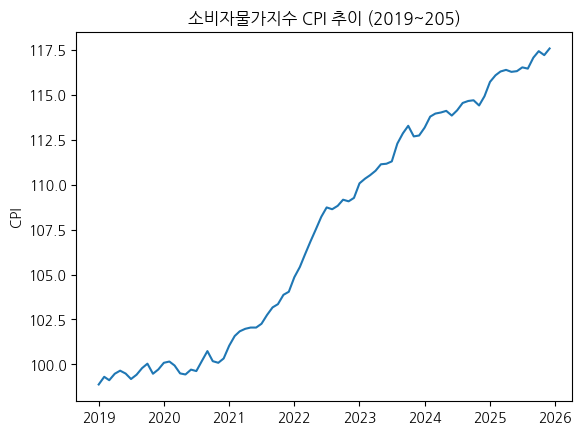

In [ ]:
plt.plot(df['date'],df['cpi'])                   # 그래프의 x축, y축의 데이터값을 지정 한다. x축(날짜), y축(cpi)

plt.title('소비자물가지수 CPI 추이 (2019~205)')  # 그래프의 제목
plt.ylabel('CPI')                                # y축 이름

plt.show()                                       # 그래프 보여줘.

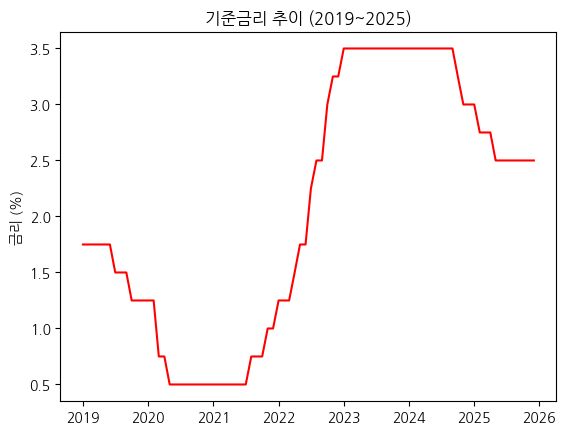

In [ ]:
plt.plot(df['date'], df['rate'], color = 'red')  # cpi와 구별을 위해 색깔을 빨간색으로 설정

plt.title('기준금리 추이 (2019~2025)')
plt.ylabel('금리 (%)')

plt.show()

# 문제점 발생

* usd_krw 이 문자 형식으로 되어있어 y축의 값이 뒤죽박죽 되었다
* usd_krw 이 문자 형식으로 되어있어 그래프 값이 직선으로 표시된다.

In [ ]:
print(df['usd_krw'].dtype)                             # 문자 형식으로 되어있다.

object


In [ ]:
df['usd_krw'] = df['usd_krw'].str.replace(',', '')     # str.replace() = 문자열에서 특정 문자를 다른 문자로 바꿔주는 코드.
                                                       # 쉼표를 빈 문자로 바꿔준다
df['usd_krw'] = df['usd_krw'].astype(float)            # 데이터 타입을 숫자 타입으로 바꿔라

In [ ]:
print(df['usd_krw'].dtype)

float64


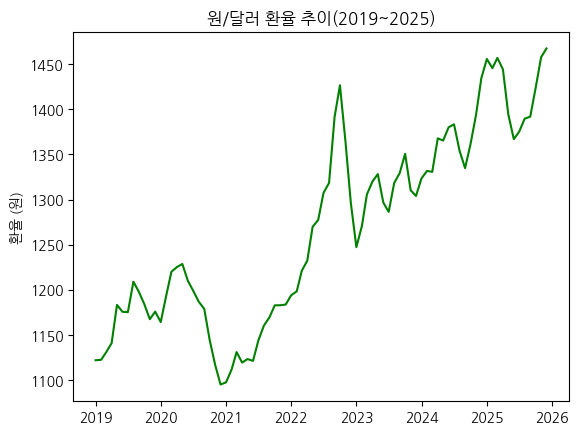

In [ ]:
plt.plot(df['date'], df['usd_krw'], color = 'green')   # 다른 그래프와 구별을 위해 색깔을 초록색으로 설정

plt.title('원/달러 환율 추이(2019~2025)')
plt.ylabel('환율 (원)')

plt.show()

# merge 를 사용했기 때문에 그래프를 한눈에 볼 수 있다

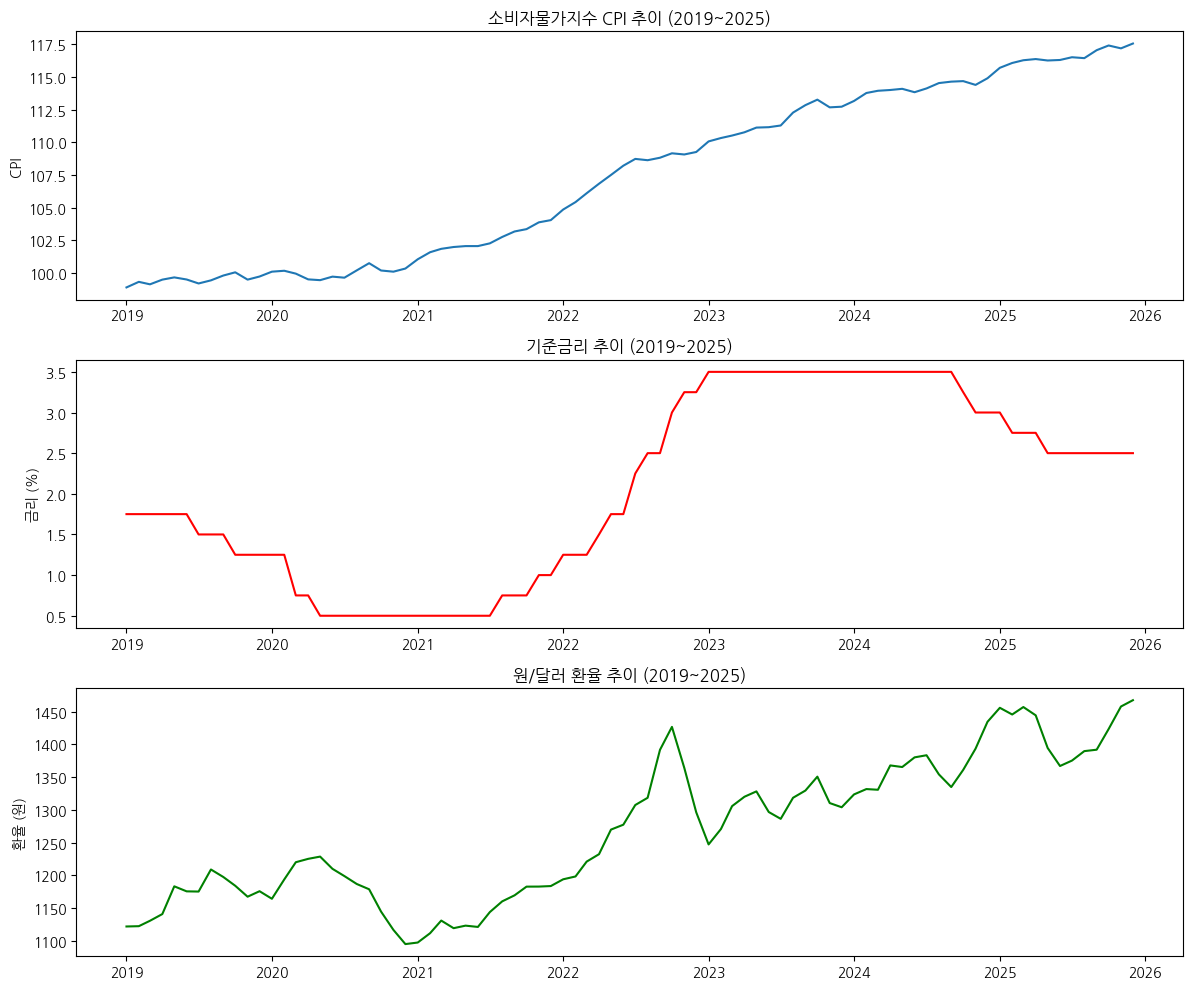

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))             # fig = 도화지 역할, axes = fig에서 나뉜 각각의 그래프 칸들을 의미 axes[0], axes[1] 이런식으로 불린다.
                                                             # plt.subplots = 도화지의 칸을 나누는 함수이다. (3,1)일때, 3행 1열의 형식으로 칸을 나눈다.
                                                             # figsize() = 도화지의 크기를 설정한다.

axes[0].plot(df['date'], df['cpi'])                          # 첫 번째 그래프 - CPI
axes[0].set_title('소비자물가지수 CPI 추이 (2019~2025)')
axes[0].set_ylabel('CPI')


axes[1].plot(df['date'], df['rate'], color='red')            # 두 번째 그래프 - 기준금리
axes[1].set_title('기준금리 추이 (2019~2025)')
axes[1].set_ylabel('금리 (%)')


axes[2].plot(df['date'], df['usd_krw'], color='green')       # 세 번째 그래프 - 환율
axes[2].set_title('원/달러 환율 추이 (2019~2025)')
axes[2].set_ylabel('환율 (원)')

plt.tight_layout()                                           # 그래프 간격 자동 조정
plt.show()

# 각 데이터들의 분석 결과

In [ ]:
cpi_start = df['cpi'].iloc[0]                               # iloc = index(번호)location(위치)의 약자 번호로 위치를 찾아준다.
                                                            # cpi의 첫번째 값을 cpi_start에 저장

cpi_end = df['cpi'].iloc[-1]                                # cpi의 마지막값(-1)을 찾아서 cpi_end에 저장

cpi_u = (cpi_end - cpi_start).round(2)                      # cpi의 상승폭을 cpi_u 변수로 저장 소수점 2자리로 반올림
                                                            # 상승폭 = 마지막값 - 시작값

cpi_up = ((cpi_end - cpi_start) / cpi_start * 100).round(2) # 상승률 = (마지막값 - 시작값) / 시작값 * 100

print(cpi_start)
print(cpi_end)
print(cpi_u)
print(cpi_up)



98.884
117.57
18.69
18.9


In [ ]:
rate_min = df['rate'].min()                                 # 기준금리의 최솟값을 rate_min 변수에 저장

print(rate_min)

rate_max = df['rate'].max()                                 # 기준금리의 최대값을 rate_max 변수에 저장

print(rate_max)

0.5
3.5


In [ ]:
usd_krw_min = df['usd_krw'].min()                           # 원/달러 환율의 최솟값을 usd_krw_min 변수에 저장

print(usd_krw_min)

usd_krw_max = df['usd_krw'].max()                           # 원/달러 환율의 최대값을 usd_krw_max 변수에 저장

print(usd_krw_max)

1095.13
1467.4


In [ ]:
print("====핵심 분석 결과 ====")

print('cpi 시작값 :', cpi_start)
print('cpi 마지막값 :', cpi_end)
print('cpi 상승폭 :', cpi_u)
print('cpi 상승률 :', cpi_up,'%')

print('기준금리 최소값 :', rate_min)
print('기준금리 최대값 :', rate_max)

print('원/달러 환율 최소값 :', usd_krw_min)
print('원/달러 환율 최대값 :', usd_krw_max)

====핵심 분석 결과 ====
cpi 시작값 : 98.884
cpi 마지막값 : 117.57
cpi 상승폭 : 18.69
cpi 상승률 : 18.9 %
기준금리 최소값 : 0.5
기준금리 최대값 : 3.5
원/달러 환율 최소값 : 1095.13
원/달러 환율 최대값 : 1467.4


# 핵심 분석 결과를 통해 Gemini API를 활용한 경제 흐름 요약

* API : Application Programming Interface

서로 다른 소프트웨어 애플리케이션이 데이터를 주고받는 기능을 서로 공유할 수 있도록 연결해주는 기능


In [ ]:
!pip install google-generativeai # 코랩에 있지 않는 도구는 !pip install로 직접 설치해야 한다
                                 # Gemini AI 도구 설치

In [ ]:
from getpass import getpass                              # 입력값을 숨겨주는 도구를 불러오기

gemini_api_key = getpass('Gemini API 키를 입력하세요:')  # API key는 사용량에따라 비용도 증가하기때문에 보안이 중요하다.

Gemini API 키를 입력하세요:··········


In [ ]:
import google.generativeai as AI                         # 설치한 제미나이를 AI로 명명하고 불러온다

AI.configure(api_key=gemini_api_key)                     # AI.configure = 제미나이를 설정한다, api_key = 위에서 입력한 API를 알려준다

model = AI.GenerativeModel('gemini-2.5-flash')           # 제미나이 모델을 설정한다

print("Gemini API 설정 완료!")                           # 과정이 완료되면 설정완료라고 출력

Gemini API 설정 완료!


/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


# AI에게 질문할 프롬프트 생성

* prompt = 질문을 저장하는 변수
* f = 변수 값을 텍스트에 넣을 수 있게 한다.
* """ = 여러 줄의 텍스트를 쓸 수 있게 한다.

In [ ]:
prompt = f"""
다음은 2019년부터 2025년까지의 한국 경제지표 분석 결과야

각 수치의 값도 표현해줘
- 소비자물가지수(CPI) 시작값: {cpi_start}
- 소비자물가지수(CPI) 마지막값: {cpi_end}
- CPI 상승폭: {cpi_u}
- CPI 상승률: {cpi_up}%
- 기준금리 최저값: {rate_min}%
- 기준금리 최고값: {rate_max}%
- 원/달러 환율 최저값: {usd_krw_min}원
- 원/달러 환율 최고값: {usd_krw_max}원

위 결과를 바탕으로 경제학을 잘 모르는 일반 사용자도 이해할 수 있도록 5문장으로 요약해줘.

조건:
1. 물가, 금리, 환율의 흐름을 쉽게 설명할 것
2. 일반 소비자와 취업준비생에게 어떤 의미가 있을 수 있는지 포함할 것
3. 데이터만으로 확인할 수 없는 인과관계는 단정하지 말 것
4. “영향을 줄 수 있다”, “가능성이 있다”처럼 신중한 표현을 사용할 것
"""

In [ ]:
response = model.generate_content(prompt)    # response = 제미나이의 답변을 저장하는 변수, model = 설정한 제미나이 모델
                                             # .generate_content() 제미나이한테 질문 내용을 보낸다.
print("=== 경제지표 분석 요약 ===")
print(response.text)                         # 답변의 텍스트만 꺼낸다.

=== 경제지표 분석 요약 ===
2019년부터 2025년까지 한국 경제는 다음과 같은 흐름을 보였습니다.

1.  소비자물가지수(CPI)가 98.884에서 117.57로 약 18.9% 상승하여, 이 기간 동안 일상생활에서 체감하는 물가 상승폭이 상당히 컸을 것으로 보입니다.
2.  기준금리는 최저 0.5%에서 최고 3.5%까지 큰 폭으로 변동했으며, 이는 대출 이자 부담을 증가시키거나 예금 이자 수입에 변화를 가져올 수 있었습니다.
3.  원/달러 환율 또한 최저 1095.13원에서 최고 1467.4원까지 올라, 수입품 가격과 해외여행 비용 상승 등에도 영향을 줄 수 있습니다.
4.  이처럼 물가 상승, 금리 변동, 그리고 환율 불안정은 일반 소비자의 구매력 감소와 가계 경제 부담 증가로 이어질 수 있었을 것으로 해석됩니다.
5.  특히 취업준비생의 경우, 전반적인 경제 상황의 불확실성 증가는 기업의 투자 및 고용 위축으로 이어져 일자리 찾기에 어려움을 가중시킬 가능성이 있습니다.
